# Baseline experiments for the diploma thesis
author: Lubojacky Jan (lubojjan@fel.cvut.cz)

In [27]:
# autoload
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, cross_val_predict, train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, make_scorer
from sklearn.svm import SVC
import optuna
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb
from xgboost import XGBClassifier

import seaborn as sn
import matplotlib.pyplot as plt

from src.baseline import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
interactions = pl.read_csv('BIOGRID-ALL-4.4.229.tab3.txt', separator='\t', null_values=['-'])
interactions.columns

In [25]:
# read featurenames into a list

# f_names = pl.read_csv('MOGLAM/BRCA_split/BRCA/1_featname.csv')
# for each row split the string by the delimiter |
# Specify the file path
file_path = 'MOGLAM/BRCA_split/BRCA/1_featname.csv'  # Replace 'your_file.txt' with the actual file path

# Open the file and read lines into a list
with open(file_path, 'r') as file:
    file_content = file.readlines()

# Optionally, strip newline characters from each line
file_content = [line.strip().split('|')[0] for line in file_content][1:]

# Now, file_content is a list where each element corresponds to a line in the file
print(file_content)

['A2ML1', 'ABAT', 'ABCA13', 'ABCC11', 'ABCC8', 'ABCG1', 'ABCG2', 'ABLIM3', 'ABTB2', 'ACADSB', 'ACE2', 'ACOT4', 'ACOX2', 'ACTL6A', 'ACTR3B', 'ACVR1B', 'ADAMTS15', 'ADCY9', 'ADD1', 'AFF3', 'AGR2', 'AGR3', 'AKR1E2', 'AKR7A3', 'ALAD', 'AMD1', 'AMY1A', 'ANKLE1', 'ANKMY1', 'ANKRA2', 'ANKRD30A', 'ANKRD30B', 'ANKRD42', 'ANKRD45', 'ANKS6', 'ANLN', 'ANP32E', 'ANXA8L2', 'ANXA9', 'APBB2', 'APH1B', 'APPL2', 'ARHGAP11A', 'ARHGEF4', 'ARL9', 'ARSG', 'ART3', 'AR', 'ASNS', 'ASTN2', 'ATAD2', 'ATL2', 'ATOH7', 'ATP1B3', 'ATP5C1', 'ATP6V1C2', 'ATP7B', 'ATP8B1', 'AURKA', 'AURKB', 'B3GNT4', 'B3GNT5', 'BAIAP2L2', 'BBOX1', 'BBS1', 'BBS4', 'BBS5', 'BCAM', 'BCAS1', 'BCL11A', 'BCL2', 'BECN1', 'BHLHE40', 'BIRC5', 'BLM', 'BPI', 'BRIX1', 'BTG2', 'BTG3', 'BUB1', 'BYSL', 'C10orf116', 'C10orf26', 'C10orf32', 'C10orf90', 'C11orf75', 'C11orf82', 'C11orf86', 'C12orf11', 'C12orf48', 'C12orf72', 'C13orf27', 'C14orf174', 'C14orf45', 'C15orf23', 'C15orf42', 'C16orf45', 'C16orf57', 'C16orf61', 'C16orf71', 'C17orf28', 'C19orf51'

In [ ]:
# select rows with human genes
human_interactions = (interactions.lazy()
                      .filter(interactions['Organism ID Interactor A'] == 9606)
                      .filter(interactions['Organism ID Interactor B'] == 9606)
                      .filter(interactions['Score'] != 'null')
).collect()
human_interactions.__len__

In [ ]:
human_interactions.head(100)

# Loading & preprocessing the data

In [2]:
# loading data
RNA = pl.read_csv("data/200625_allRNA_fromRNAseq_annot_hg38.tsv", separator="\t") # mix of different RNA types
circRNA = pl.read_csv("data/200625_circRNA_fromRNAseq_annot_hg19.tsv", separator="\t",  null_values=["NA"]) # circRNA
piRNA = pl.read_excel("data/piRNA_counts.xlsx", engine="xlsx2csv") # piRNA
miRNA = pl.read_excel("data/final_all_samples_miRNA_seq.xlsx", engine="xlsx2csv") # miRNA
sampleSheet = pl.read_excel("data/sample sheet for CVUT.xlsx", engine="xlsx2csv") # annotations

In [3]:
print("RNA: ", RNA.shape)
print("circRNA: ", circRNA.shape)
print("piRNA: ", piRNA.shape)
print("miRNA: ", miRNA.shape)
print("sampleSheet: ", sampleSheet.shape)

RNA:  (58216, 92)
circRNA:  (51018, 95)
piRNA:  (556, 105)
miRNA:  (2553, 106)
sampleSheet:  (98, 9)


In [8]:
# # find names which are both in RNA and sample sheet
# sampleSheet_names = sampleSheet["SAMPLE_NAME"].to_list()
# RNA_names = RNA.columns
# piRNA_names = piRNA.columns
# miRNA_names = miRNA.columns
# circRNA_names = circRNA.columns

# print(sampleSheet_names)
# # print(RNA_names)
# print(f"{piRNA_names=}")
# print(f"{miRNA_names=}")
# print(f"{circRNA_names=}")

# # # in the piRNA_names and miRNA_names remove the "-UMIs" suffix from the names
# # sampleSheet_names = [name.split('_')[0] for name in sampleSheet_names]
# # RNA_names = [name.split('_')[0] for name in RNA_names]
# # piRNA_names = [name.split('_')[0] for name in piRNA_names]
# # miRNA_names = [name.split('_')[0] for name in miRNA_names]
# # circRNA_names = [name.split('_')[0] for name in circRNA_names]

# # print(sampleSheet_names)
# # print(f"{RNA_names=}")
# # print(f"{piRNA_names=}")
# # print(f"{miRNA_names=}")
# # print(f"{circRNA_names=}")

# # RNA.columns[6:] = RNA_names # remove the pattern
# # piRNA.columns = piRNA_names # remove the pattern
# # miRNA.columns = miRNA_names # remove the pattern
# # circRNA.columns = circRNA_names

# # remove the pattern

# print(sampleSheet_names)
# print(RNA_names)
# # return

# # find names which are both in sampleSheet_names and RNA_names
# # common_names = list(set(sampleSheet_names) & set(RNA_names)
# common_names = set(sampleSheet_names).intersection(
#     RNA_names #, circRNA_names, piRNA_names, miRNA_names
# )
# # common_names.sort()
# print("Number of common names: ", len(common_names))
# print(common_names)

# find names which are both in RNA and sample sheet
sampleSheet_names = sampleSheet["SAMPLE_NAME"].to_list()
RNA_names = RNA.columns
piRNA_names = piRNA.columns
miRNA_names = miRNA.columns
circRNA_names = circRNA.columns

# in the piRNA_names and miRNA_names remove the "-UMIs" suffix from the names
# piRNA_names = [name[:-5] for name in piRNA_names]
# miRNA_names = [name[:-5] for name in miRNA_names]

print(sampleSheet_names)
# print(RNA_names)
print(f"{piRNA_names=}")
print(f"{miRNA_names=}")
print(f"{circRNA_names=}")

# find names which are both in sampleSheet_names and RNA_names
# common_names = list(set(sampleSheet_names) & set(RNA_names)
common_names = set(sampleSheet_names).intersection(
    circRNA_names# piRNA_names # , miRNA_names
)

common_names = list(common_names)
common_names.sort()

print("Number of common names: ", len(common_names))
print(common_names)

['N54_S14', 'N58_S18', 'N60_S15', 'N70_S16', 'N82_S1', 'N83_S3', 'N84_S4', 'N85_S19', 'N86_S13', 'N87_S20', 'NV1428_S3', 'NV911_S19', 'NV912_S20', 'V1776_S9', 'V2110_S16', 'V2224_S17', 'V2241_S15', 'V2248_S18', 'V2322_S20', 'V2414_S25', 'V630_S11', 'V1528_S12', 'V1860_S18', 'V2133_S43', 'V1505_S10', 'V1591_S14', 'V456_S4', 'V513_S16', 'V637_S21', 'V1874_S1', 'V777_S20', 'V1800_S1', 'V359_S3', 'V382_S22', 'V406_S18', 'V220_S6', 'V2286_S1', 'V716_S1', 'V806_S1', 'V888_S2', 'V956_S6', 'V125_S5', 'V1321_S4', 'V1788_S2', 'V1456_S13', 'V108_S5', 'V624_S15', 'V1048_S12', 'V2368_S3', 'V1565_S13', 'V1422_S6', 'V1708_S22', 'V1920_S14', 'V2089_S9', 'V2284_S4', 'V2378_S5', 'V553_S11', 'V1699_S2', 'V1742_S5', 'V1823_S7', 'V1834_S7', 'V2092_S3', 'V344_S16', 'V67_S6', 'V883_S4', 'V940_S8', 'V712_S22', 'V1279_S21', 'V148_S10', 'V2278_S19', 'V1857_S8', 'V1664_S23', 'V480_S7', 'V100_S45', 'V2115_S9', 'V538_S12', 'V76_S21', 'V839_S17', 'V1744_S46', 'V2147_S10', 'V2179_S11', 'V1441_S2', 'V1592_S5', 'V1689

**Create input data**
- each row in RNA_X is one sample
- and we have the labels for 3 classification tasks, binary disease, 3-class risk and 3-class mutation

In [112]:
# RNA_X = (RNA.lazy()         
#          .select(common_names)
#          .collect()).to_numpy().T

# circRNA_X = (circRNA.lazy()
#                 .select(common_names)
#                 .collect()).to_numpy().T

# piRNA_X = (piRNA.lazy()
#                 .select(common_names)
#                 .collect()).to_numpy().T

# miRNA_X = (miRNA.lazy()
#                 .select(common_names)
#                 .collect()).to_numpy().T

In [9]:
RNA_X = (RNA.lazy()         
         .select(common_names)
         .collect()).to_numpy().T

# drop features with zero variance
non_zero_variance = np.var(RNA_X, axis=0) != 0
print(non_zero_variance)

print(RNA_X.shape)
RNA_X = RNA_X[:, non_zero_variance]
print(RNA_X.shape, " after dropping features with zero variance")

features_kept = RNA.select("GENE_ID").to_numpy().flatten()[non_zero_variance]
print(features_kept)

# log transform RNA_X
RNA_X = np.log2(RNA_X + 1)

# normalize RNA_X by columns
RNA_X = (RNA_X - np.mean(RNA_X, axis=0)) / np.std(RNA_X, axis=0)

y = (sampleSheet.lazy()
    .filter(pl.col('SAMPLE_NAME').is_in(common_names))
    .sort("SAMPLE_NAME")
    .select(["1 disease", "2 risk", "3 mutations (SF3B1only_wt)"])
    .collect()).to_numpy()
y_disease, y_risk, y_mutation = y[:, 0] - 1, y[:, 1], y[:, 2] # -1 to make it 0/1 instead of 1/2

print(RNA_X)

print("#### CLASSES COUNTS ####")
print(np.unique(y_disease, return_counts=True))
print(np.unique(y_risk, return_counts=True))
print(np.unique(y_mutation, return_counts=True))

[ True  True  True ...  True  True  True]
(74, 58216)
(74, 57915)  after dropping features with zero variance
['ENSG00000242268' 'ENSG00000188026' 'ENSG00000270112' ...
 'ENSG00000181518' 'ENSG00000231119' 'ENSG00000232940']
[[ 0.56174161  1.05239033  0.31017343 ... -0.80342851  1.33216296
   1.05121798]
 [ 0.21056012  0.12892652  0.57134879 ... -0.80342851  0.65037022
   1.00321633]
 [ 0.47456166  0.19206079  2.00662895 ... -0.80342851  1.18278334
   0.80086069]
 ...
 [ 0.11172365  1.30887811  1.04134655 ...  0.46142262  0.16912648
   1.36398434]
 [-0.20365297  0.86452158  0.64113971 ... -0.80342851 -2.98191509
  -1.58388777]
 [ 0.04869204 -0.35636178 -1.11472003 ...  1.2013131  -4.34536866
   0.549739  ]]
#### CLASSES COUNTS ####
(array([0, 1]), array([13, 61]))
(array([0, 1, 2]), array([21, 29, 24]))
(array([0, 1, 2]), array([48, 13, 13]))


In [13]:
RNA_X = (RNA.lazy()         
         .select(common_names)
         .collect()).to_numpy().T

# drop features with zero variance
non_zero_variance = np.var(RNA_X, axis=0) != 0
print(non_zero_variance)

print(RNA_X.shape)
RNA_X = RNA_X[:, non_zero_variance]
print(RNA_X.shape, " after dropping features with zero variance")

features_kept = RNA.select("GENE_ID").to_numpy().flatten()[non_zero_variance]
print(features_kept)

# log transform RNA_X
# RNA_X = np.log2(RNA_X + 1)

# normalize RNA_X by columns
# RNA_X = (RNA_X - np.mean(RNA_X, axis=0)) / np.std(RNA_X, axis=0)

y = (sampleSheet.lazy()
    .filter(pl.col('SAMPLE_NAME').is_in(common_names))
    .sort("SAMPLE_NAME")
    .select(["1 disease", "2 risk", "3 mutations (SF3B1only_wt)"])
    .collect()).to_numpy()
y_disease, y_risk, y_mutation = y[:, 0] - 1, y[:, 1], y[:, 2] # -1 to make it 0/1 instead of 1/2

print(RNA_X)

print("#### CLASSES COUNTS ####")
print(np.unique(y_disease, return_counts=True))
print(np.unique(y_risk, return_counts=True))
print(np.unique(y_mutation, return_counts=True))

[ True  True  True ...  True  True  True]
(74, 58216)
(74, 57915)  after dropping features with zero variance
['ENSG00000242268' 'ENSG00000188026' 'ENSG00000270112' ...
 'ENSG00000181518' 'ENSG00000231119' 'ENSG00000232940']
[[ 89 407   6 ...   0  96 165]
 [ 55 235   9 ...   0  55 159]
 [ 79 244  70 ...   0  85 136]
 ...
 [ 48 474  18 ...   3  37 210]
 [ 31 364  10 ...   0   2  21]
 [ 44 176   0 ...   8   0 112]]
#### CLASSES COUNTS ####
(array([0, 1]), array([13, 61]))
(array([0, 1, 2]), array([21, 29, 24]))
(array([0, 1, 2]), array([48, 13, 13]))


In [16]:
RNA_X[1], y[1]

(array([ 55, 235,   9, ...,   0,  55, 159]), array([1, 0, 0]))

In [21]:
# drop features with zero variance
# non_zero_variance = np.var(RNA_X, axis=0) != 0

RNA_X = (RNA.lazy()         
         .select(common_names)
         .collect()).to_numpy().T

# drop features with less than 100 counts
RNA_X = RNA_X[:, RNA_X.sum(axis=0) > 1000]

print(RNA_X.shape)

# log10 transform
RNA_X = np.log2(RNA_X + 1)

# drop features with variance less than 0.1
RNA_X = RNA_X[:, np.var(RNA_X, axis=0) > 1]

# normalize RNA_X by columns
RNA_X = (RNA_X - np.mean(RNA_X, axis=0)) / np.std(RNA_X, axis=0)

# pca transform onto 200 components
pca = PCA(n_components=50, svd_solver='auto')
RNA_X = pca.fit_transform(RNA_X)

print(RNA_X.shape)

# print(RNA_X.shape)

# np.var(RNA_X, axis=0).shape

# plt.hist(feature_counts, bins=100)
# plt.show()

# np.histogram(feature_counts, bins=100)

# log2 transform
# RNA_X = np.log2(RNA_X + 1)

# # variation filtering
# # RNA_X.var(axis=0).shape

# # get counts of each feature
# RNA_X.sum(axis=0)

# # RNA_X = RNA_X[:, non_zero_variance]
# # print(RNA_X.shape, " after dropping features with zero variance")

# features_kept = RNA.select("GENE_ID").to_numpy().flatten()[non_zero_variance]
# print(features_kept)

# # normalize RNA_X by columns
# # 

y = (sampleSheet.lazy()
    .filter(pl.col('SAMPLE_NAME').is_in(common_names))
    .sort("SAMPLE_NAME")
    .select(["1 disease", "2 risk", "3 mutations (SF3B1only_wt)"])
    .collect()).to_numpy()
y_disease, y_risk, y_mutation = y[:, 0] - 1, y[:, 1], y[:, 2] # -1 to make it 0/1 instead of 1/2

print("#### CLASSES COUNTS ####")
print(np.unique(y_disease, return_counts=True))
print(np.unique(y_risk, return_counts=True))
print(np.unique(y_mutation, return_counts=True))

(74, 25925)
(74, 50)
#### CLASSES COUNTS ####
(array([0, 1]), array([13, 61]))
(array([0, 1, 2]), array([21, 29, 24]))
(array([0, 1, 2]), array([48, 13, 13]))


**Data exploration / visualization with PCA**

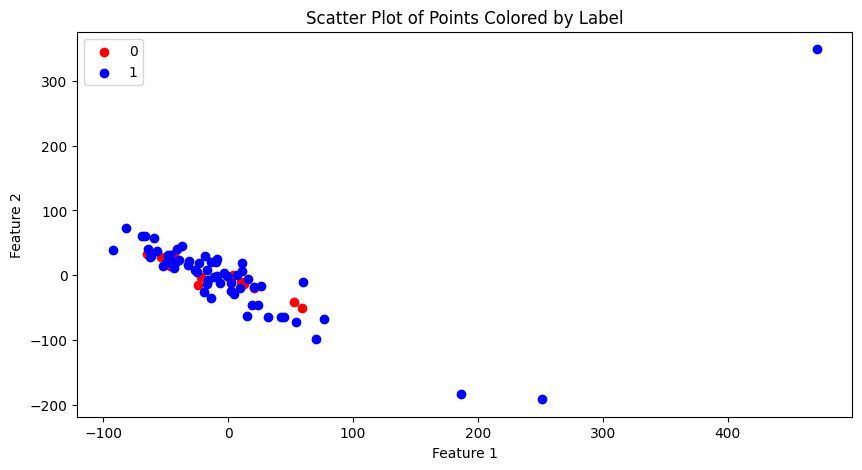

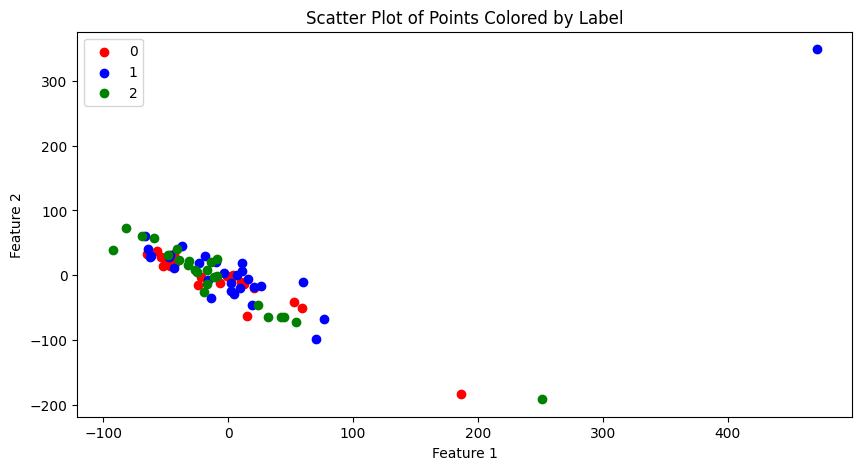

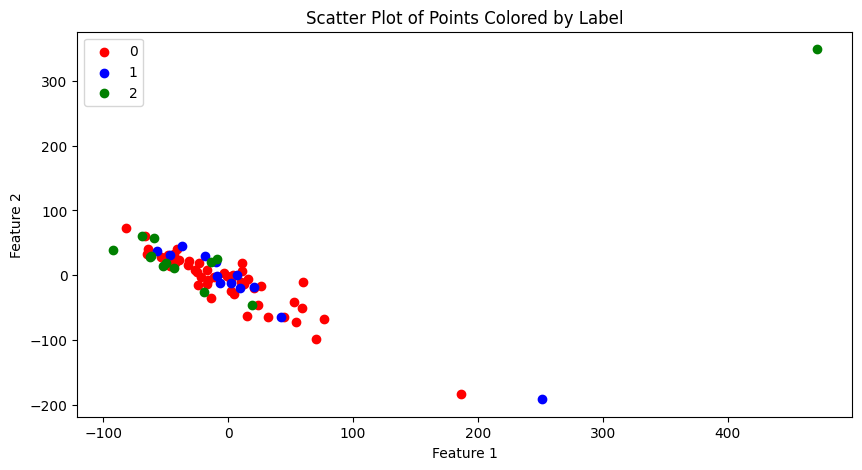

In [18]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

pca = PCA(n_components=2)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

def visualize_and_color_by_class(X, y):

    # split X by class and plot
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'black', 'yellow']
    plt.figure(figsize=(10, 5))

    for i in range(len(np.unique(y))):
        X_i = X[y == i]
        plt.scatter(X_i[:, 0], X_i[:, 1], label=str(i), color=colors[i])

    # Add labels and legend
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter Plot of Points Colored by Label')
    plt.legend()

    # Show the plot
    plt.show()

visualize_and_color_by_class(RNA_pca, y_disease)
visualize_and_color_by_class(RNA_pca, y_risk)
visualize_and_color_by_class(RNA_pca, y_mutation)

# KNN

In [23]:
print("\nKNN evaluation on all RNA for disease:")
_ = KNN_evaluation(RNA_X, y_disease)
print("\nKNN evaluation on all RNA for risk:")
_ = KNN_evaluation(RNA_X, y_risk)
print("\nKNN evaluation on all RNA for mutation:")
_ = KNN_evaluation(RNA_X, y_mutation)


KNN evaluation on all RNA for disease:
Best k:  1
Cross Validation Results:
| KNN | 0.86 ± 0.06 | 0.79 +/- 0.07 | 0.87 +/- 0.05

Best k:  2
Cross Validation Results:
| KNN | 0.70 ± 0.08 | 0.66 +/- 0.07 | 0.74 +/- 0.07

Best k:  3
Cross Validation Results:
| KNN | 0.86 ± 0.06 | 0.79 +/- 0.08 | 0.87 +/- 0.05

Best k:  4
Cross Validation Results:
| KNN | 0.74 ± 0.12 | 0.67 +/- 0.12 | 0.76 +/- 0.10

Best k:  5
Cross Validation Results:
| KNN | 0.83 ± 0.09 | 0.76 +/- 0.11 | 0.85 +/- 0.08

Best k:  6
Cross Validation Results:
| KNN | 0.75 ± 0.10 | 0.70 +/- 0.09 | 0.78 +/- 0.09

Best k:  7
Cross Validation Results:
| KNN | 0.82 ± 0.10 | 0.73 +/- 0.11 | 0.83 +/- 0.08

Best k:  8
Cross Validation Results:
| KNN | 0.74 ± 0.10 | 0.67 +/- 0.10 | 0.77 +/- 0.09

Best k:  9
Cross Validation Results:
| KNN | 0.84 ± 0.08 | 0.73 +/- 0.09 | 0.84 +/- 0.06


KNN evaluation on all RNA for risk:
Best k:  1
Cross Validation Results:
| KNN | 0.49 ± 0.07 | 0.47 +/- 0.07 | 0.46 +/- 0.07

Best k:  2
Cross Valida

## We can increase the accuracy by a significant margin using PCA to reduce the dimensionality of the data

**NOTE:** the [MoGCN](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8847688/) paper reports that using a more sophisticated DR method such as Autoencoders further increases the accuracy of the model, especially as the dimensionality of the training data increases, we could also try that later


**NOTE 2:** We would also probably get better results by tuning the number of neighbours and PCA features simultaneously, but designing the best possible kNN model is not the goal of this thesis


In [15]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

best_PCA_components_disease = 1
best_disease_score = 0
best_PCA_components_risk = 1
best_risk_score = 0
best_PCA_components_mutation = 1
best_mutation_score = 0

for i in range(1, 30):
    pca = PCA(n_components=i)
    pca.fit(RNA_scaled)
    RNA_pca = pca.transform(RNA_scaled)

    score_d = KNN_evaluation(RNA_pca, y_disease, verbose=False)
    score_r = KNN_evaluation(RNA_pca, y_risk, verbose=False)
    score_m = KNN_evaluation(RNA_pca, y_mutation, verbose=False)

    if score_d > best_disease_score:
        best_PCA_components_disease = i
        best_disease_score = score_d
    if score_r > best_risk_score:
        best_PCA_components_risk = i
        best_risk_score = score_r
    if score_m > best_mutation_score:
        best_PCA_components_mutation = i
        best_mutation_score = score_m

print("Best number of PCA components for disease: ", best_PCA_components_disease)
print("Best number of PCA components for risk: ", best_PCA_components_risk)
print("Best number of PCA components for mutation: ", best_PCA_components_mutation)

Best number of PCA components for disease:  15
Best number of PCA components for risk:  11
Best number of PCA components for mutation:  26


In [16]:
pca_components = 15

RNA_scaled = RNA_X

print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=15)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_disease)

print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=11)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_risk)

print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=26)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_mutation)

RNA all evaluation, on PCA reduced data (disease):
Best k:  1
Cross Validation Results:
| KNN | 0.78 ± 0.03 | 0.53 +/- 0.07 | 0.76 +/- 0.02

Best k:  2
Cross Validation Results:
| KNN | 0.74 ± 0.04 | 0.50 +/- 0.06 | 0.73 +/- 0.02

Best k:  3
Cross Validation Results:
| KNN | 0.82 ± 0.03 | 0.53 +/- 0.09 | 0.78 +/- 0.04

Best k:  4
Cross Validation Results:
| KNN | 0.78 ± 0.04 | 0.50 +/- 0.07 | 0.75 +/- 0.03

Best k:  5
Cross Validation Results:
| KNN | 0.82 ± 0.02 | 0.45 +/- 0.00 | 0.75 +/- 0.01

Best k:  6
Cross Validation Results:
| KNN | 0.82 ± 0.03 | 0.47 +/- 0.05 | 0.76 +/- 0.03

Best k:  7
Cross Validation Results:
| KNN | 0.83 ± 0.01 | 0.45 +/- 0.00 | 0.76 +/- 0.01

Best k:  8
Cross Validation Results:
| KNN | 0.83 ± 0.00 | 0.45 +/- 0.00 | 0.76 +/- 0.00

Best k:  9
Cross Validation Results:
| KNN | 0.83 ± 0.00 | 0.45 +/- 0.00 | 0.76 +/- 0.00

Best k:  10
Cross Validation Results:
| KNN | 0.83 ± 0.00 | 0.45 +/- 0.00 | 0.76 +/- 0.00

Best k:  11
Cross Validation Results:
| KNN | 0.

# SVM
- as the number of features is very high we will use PCA here from the start to reduce the dimensionality of the data and speed up the training & parameter tuning
- we also tried two different kernels, linear and rbf, but the linear kernel performed much better in all cases

In [17]:
def SVM_evaluation(X, y, verbose=True):

    # Instantiate a SVM classifier
    svm = SVC(kernel='rbf', probability=True)

    # Set up the parameter grid for GridSearchCV
    param_grid = {'C': np.linspace(10**-4, 10, 10), 'gamma': np.linspace(10**-4, 10, 10)}

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        # 'roc_auc_macro': make_scorer(roc_auc_score, multi_class='ovo', average='macro'),
        # 'roc_auc_weighted': make_scorer(roc_auc_score, multi_class='ovo', average='weighted')
    }

    # Use GridSearchCV to find the best k
    grid_search = GridSearchCV(svm, param_grid, scoring=scoring_metrics, cv=5, refit='accuracy', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_C = grid_search.best_params_['C']
    best_gamma = grid_search.best_params_['gamma']

    # Train the model with the best k
    best_svm = SVC(kernel='rbf', probability=True, C=best_C, gamma=best_gamma)
    # best_svm.fit(X, y)

    if verbose:
        print(f'Best C: {best_C}')
        print(f'Best gamma: {best_gamma}')

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_svm, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    if verbose:
        # Display the results
        print("\nCross Validation Results:")
        print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
        print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
        print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')


    return cv_results["test_f1_weighted"].mean() + cv_results["test_accuracy"].mean() + cv_results["test_f1_macro"].mean()

In [74]:
print("RNA all evaluation (disease):")
_ = SVM_evaluation(RNA_X, y_disease, verbose=True)
print("RNA all evaluation (mutation):")
_ = SVM_evaluation(RNA_X, y_mutation, verbose=True)
print("RNA all evaluation (risk):")
_ = SVM_evaluation(RNA_X, y_risk, verbose=True)

RNA all evaluation (disease):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.82 +/- 0.03
F1 Macro: 0.45 +/- 0.01
F1 Weighted: 0.75 +/- 0.04
RNA all evaluation (mutation):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.65 +/- 0.03
F1 Macro: 0.26 +/- 0.01
F1 Weighted: 0.51 +/- 0.03
RNA all evaluation (risk):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.39 +/- 0.03
F1 Macro: 0.19 +/- 0.01
F1 Weighted: 0.22 +/- 0.03


In [24]:
Cs = np.logspace(-6, 2, 10)

score_disease = np.zeros(len(Cs))
score_risk = np.zeros(len(Cs))
score_mutation = np.zeros(len(Cs))

for i, C in enumerate(Cs):
    print(f"C: {C}")
    print("\nRNA all evaluation (disease):")
    score_disease[i] = svm_evaluation_linear(RNA_X, y_disease, verbose=False, C=C)
    print("\nRNA all evaluation (mutation):")
    score_mutation[i] = svm_evaluation_linear(RNA_X, y_mutation, verbose=False, C=C)
    print("\nRNA all evaluation (risk):")
    score_risk[i] = svm_evaluation_linear(RNA_X, y_risk, verbose=False, C=C)

C: 1e-06

RNA all evaluation (disease):

Cross Validation Results:
Accuracy: 0.80 +/- 0.00
F1 Macro: 0.44 +/- 0.00
F1 Weighted: 0.71 +/- 0.00

RNA all evaluation (mutation):

Cross Validation Results:
Accuracy: 0.67 +/- 0.00
F1 Macro: 0.27 +/- 0.00
F1 Weighted: 0.53 +/- 0.00

RNA all evaluation (risk):

Cross Validation Results:
Accuracy: 0.40 +/- 0.00
F1 Macro: 0.19 +/- 0.00
F1 Weighted: 0.23 +/- 0.00
C: 7.742636826811277e-06

RNA all evaluation (disease):

Cross Validation Results:
Accuracy: 0.80 +/- 0.00
F1 Macro: 0.44 +/- 0.00
F1 Weighted: 0.71 +/- 0.00

RNA all evaluation (mutation):

Cross Validation Results:
Accuracy: 0.67 +/- 0.00
F1 Macro: 0.27 +/- 0.00
F1 Weighted: 0.53 +/- 0.00

RNA all evaluation (risk):

Cross Validation Results:
Accuracy: 0.43 +/- 0.04
F1 Macro: 0.28 +/- 0.06
F1 Weighted: 0.32 +/- 0.06
C: 5.994842503189409e-05

RNA all evaluation (disease):

Cross Validation Results:
Accuracy: 0.90 +/- 0.03
F1 Macro: 0.81 +/- 0.08
F1 Weighted: 0.89 +/- 0.04

RNA all evalu

KeyboardInterrupt: 

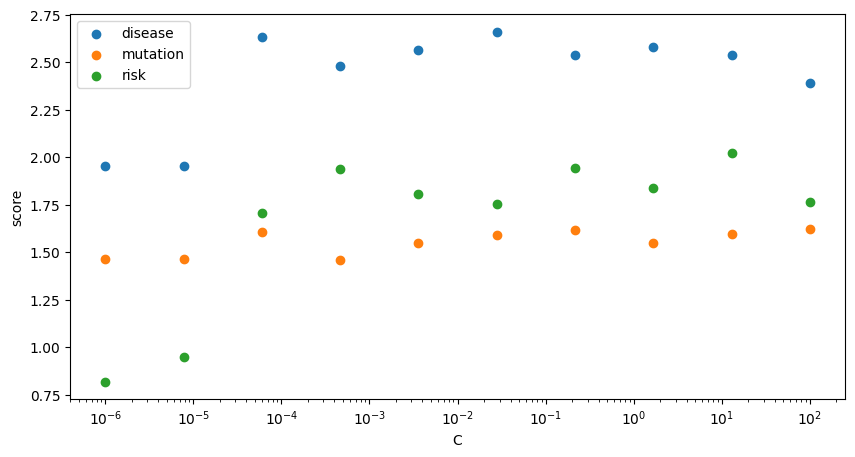

Best C for disease:  0.02782559402207126
Best C for mutation:  100.0
Best C for risk:  12.915496650148826


In [23]:
# plot with log scale
# show as scatter plot with coordinates (C, score) at each point
plt.figure(figsize=(10, 5))
plt.scatter(Cs, score_disease, label="disease")
plt.scatter(Cs, score_mutation, label="mutation")
plt.scatter(Cs, score_risk, label="risk")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("score")
plt.legend()
plt.show()

# print the best C for each class
print("Best C for disease: ", Cs[np.argmax(score_disease)])
print("Best C for mutation: ", Cs[np.argmax(score_mutation)])
print("Best C for risk: ", Cs[np.argmax(score_risk)])

# Scores for the best C

**DISEASE C=0.002**  
Accuracy: 0.91 +/- 0.06  
F1 Macro: 0.81 +/- 0.16  
F1 Weighted: 0.89 +/- 0.08  

**MUTATION C=2.78**  
Cross Validation Results:  
Accuracy: 0.66 +/- 0.10  
F1 Macro: 0.43 +/- 0.17  
F1 Weighted: 0.61 +/- 0.11  

**RISK C=16.68**  
Cross Validation Results:  
Accuracy: 0.66 +/- 0.11  
F1 Macro: 0.64 +/- 0.12  
F1 Weighted: 0.65 +/- 0.11  

## SVMs with recursive feature selection

In [25]:
# split RNA_X into a train and test set
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(RNA_X, y_disease, train_size=0.5, stratify=y_disease)
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(RNA_X, y_risk, train_size=0.5, stratify=y_risk)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(RNA_X, y_mutation, train_size=0.5, stratify=y_mutation)

In [27]:
Cs = np.logspace(-4, 2, 10)
features_kept = [50, 100, 500]

grid_size = (len(Cs), len(features_kept))
score_disease = np.zeros(grid_size)
# score_risk = np.zeros(grid_size)
# score_mutation = np.zeros(grid_size)

for i, C in enumerate(Cs):
    for j, features in enumerate(features_kept):
        print(f"C: {C}")
        print(f"features: {features}")

        # run the cross validation feature selection
        # to tune the features on the training set
        results = svm_crossval_feature_selection(X_d_train, y_d_train, C=C, features_to_select=features)

        # evaluate the best features on the test set
        X_d_test_best100 = X_d_test[:, results['best_features_i']]

        svm = SVC(kernel='linear', probability=True, C=C)
        score_disease[i][j] = svm_evaluation_linear(X_d_test_best100, y_d_test)

C: 0.0001
features: 50
Accuracy: 0.88 +/- 0.00
F1 Macro: 0.47 +/- 0.00
F1 Weighted: 0.82 +/- 0.00
Best ranks: [46772 56619 35816  4944 44016 16300 28959 30857 49134  8675 47293 22741
  3220 53808  3435 21510 39616 14831  3671 37805 11425 43284 34744 54400
 41964 46103   989 37852 40255 37033 43805  8232  6589 21906 38911 12938
  2533 21000 42307 57679 16812 35717 34453 36682 20891 44201 23954 25180
 47842 38195]
Ranks: [1.  1.  1.  1.  1.  1.  1.2 1.2 1.2 1.2 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.6
 1.6 1.6 1.6 1.6 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8
 1.8 1.8 1.8 1.8 1.8 1.8 2.  2.  2.  2.  2.  2.  2.  2. ]

Cross Validation Results:
Accuracy: 0.94 +/- 0.06
F1 Macro: 0.90 +/- 0.10
F1 Weighted: 0.93 +/- 0.07
C: 0.0001
features: 100
Accuracy: 0.88 +/- 0.00
F1 Macro: 0.47 +/- 0.00
F1 Weighted: 0.82 +/- 0.00
Best ranks: [16300 28959 56619  3435 21510 35816 46772  3220  4944 49134 44016 53808
  8675 30857  2533 20891 47293 38911 22741 39616 14831 42307 43284 11425
 21000  8059 3

KeyboardInterrupt: 

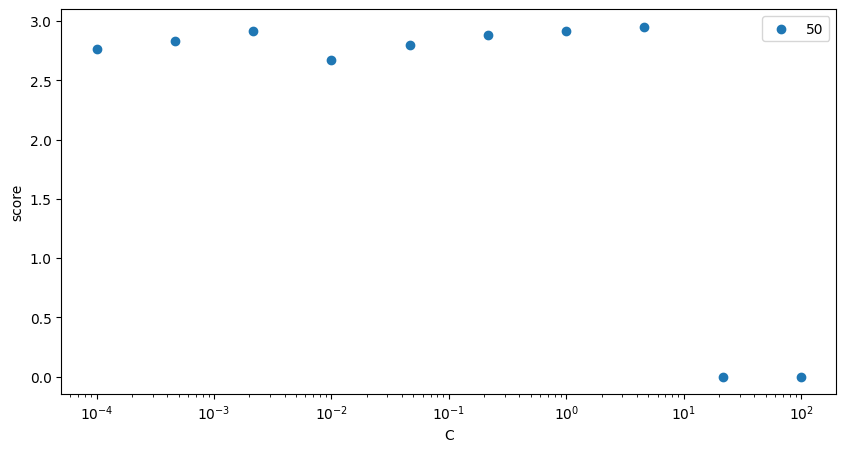

Best C for disease with 50  4.641588833612772


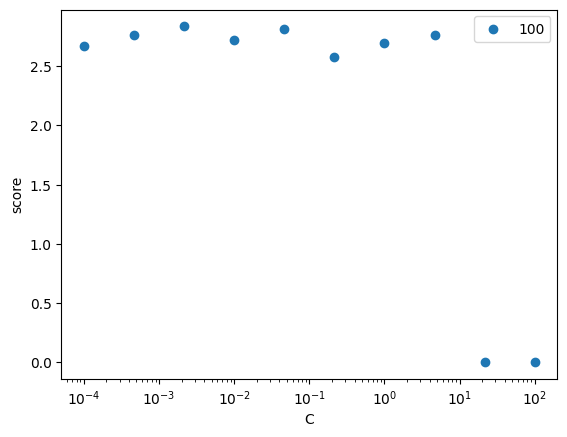

Best C for disease with 100  0.002154434690031882


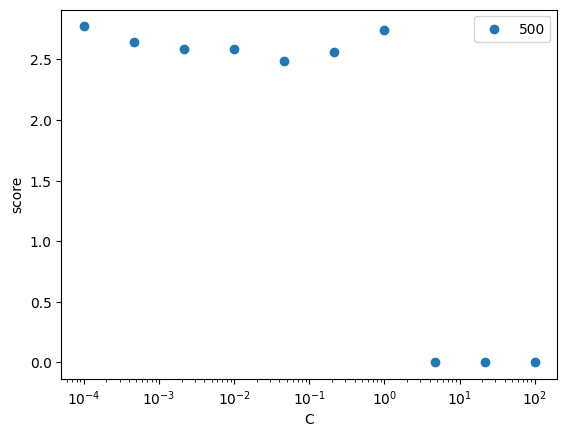

Best C for disease with 500  0.0001


In [28]:
# plot with log scale for each feature size
# show as scatter plot with coordinates (C, score) at each point
plt.figure(figsize=(10, 5))
for j, features in enumerate(features_kept):
    plt.scatter(Cs, score_disease[:, j], label=str(features))
    plt.xscale("log")
    plt.xlabel("C")
    plt.ylabel("score")
    plt.legend()
    plt.show()

    # print the best C for each class
    print(f"Best C for disease with {features} ", Cs[np.argmax(score_disease[:, j])])

In [30]:
# position of the highest score in the score matrix
i, j = np.unravel_index(np.argmax(score_disease), score_disease.shape)
print(i, j)
print("Best C for disease: ", Cs[i])
print("Best features for disease: ", features_kept[j])

7 0
Best C for disease:  4.641588833612772
Best features for disease:  50


In [34]:
def plot_feature_selection_results(Cs, scores, features_kept):
    # plot with log scale for each feature size
    # show as scatter plot with coordinates (C, score) at each point
    plt.figure(figsize=(10, 5))
    for j, features in enumerate(features_kept):
        plt.scatter(Cs, scores[:, j], label=str(features))
        plt.xscale("log")
        plt.xlabel("C")
        plt.ylabel("score")
        plt.legend()
        plt.show()

        # print the best C for each class
        print(f"Best C for disease with {features} ", Cs[np.argmax(scores[:, j])])

    # position of the highest score in the score matrix
    i, j = np.unravel_index(np.argmax(scores), scores.shape)
    print(i, j)
    print("Best C for disease: ", Cs[i])
    print("Best features for disease: ", features_kept[j])

**DISEASE**  
Accuracy: 0.85 +/- 0.09  
F1 Macro: 0.74 +/- 0.19  
F1 Weighted: 0.82 +/- 0.12  

In [31]:
Cs = np.logspace(-4, 2, 10)
features_kept = [50, 100, 500]

grid_size = (len(Cs), len(features_kept))

score_risk = np.zeros(grid_size)

for i, C in enumerate(Cs):
    for j, features in enumerate(features_kept):
        print(f"C: {C}")
        print(f"features: {features}")

        # run the cross validation feature selection
        # to tune the features on the training set
        results = svm_crossval_feature_selection(X_r_train, y_r_train, C=C, features_to_select=features)

        # evaluate the best features on the test set
        X_r_test_best100 = X_r_test[:, results['best_features_i']]

        svm = SVC(kernel='linear', probability=True, C=C)
        score_risk[i][j] = svm_evaluation_linear(X_r_test_best100, y_r_test)

C: 0.0001
features: 50
Accuracy: 0.38 +/- 0.00
F1 Macro: 0.18 +/- 0.00
F1 Weighted: 0.20 +/- 0.00
Best ranks: [55685 18415 45860 19278 49857 36400 36682 23588 22953  5629 35036  9490
  9819  7506 16407 40458 11497  5707 19511 19659 27492 52556 46940 56420
 43838 57024 29246 29665 22964  5233 12583  5030 21275 29286 39946 32632
 27237 47974 36959 35350   596 54690 22397 55643 31919 21597 31526  8594
 45439  9648]
Ranks: [1.  1.  1.  1.2 1.2 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.6 1.6 1.6 1.6
 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.8 1.8 1.8 1.8 1.8 1.8
 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8]

Cross Validation Results:
Accuracy: 0.53 +/- 0.12
F1 Macro: 0.47 +/- 0.15
F1 Weighted: 0.48 +/- 0.15
C: 0.0001
features: 100
Accuracy: 0.38 +/- 0.00
F1 Macro: 0.18 +/- 0.00
F1 Weighted: 0.20 +/- 0.00
Best ranks: [36400 45860 35036  7506 49857 18415 55685  9819 40458 19278 11497  9490
  5629 12583  2704 36682 57024 29246 10449 19511 34541 46940   596 23588
 21597 16407 2

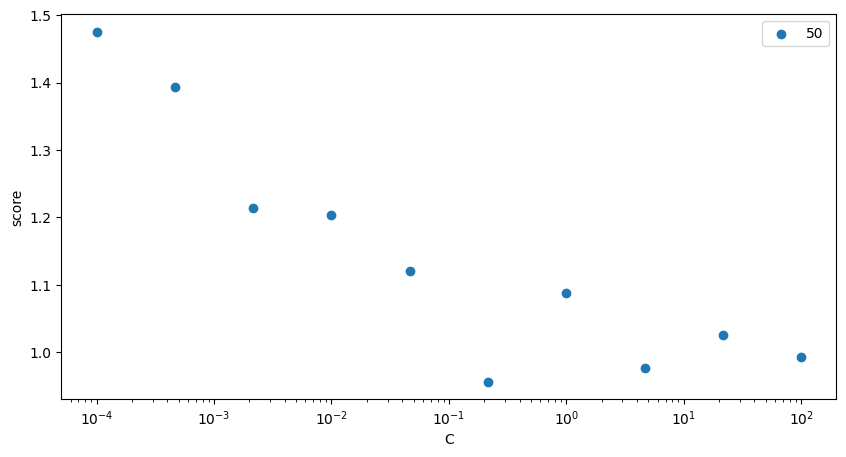

Best C for disease with 50  0.0001


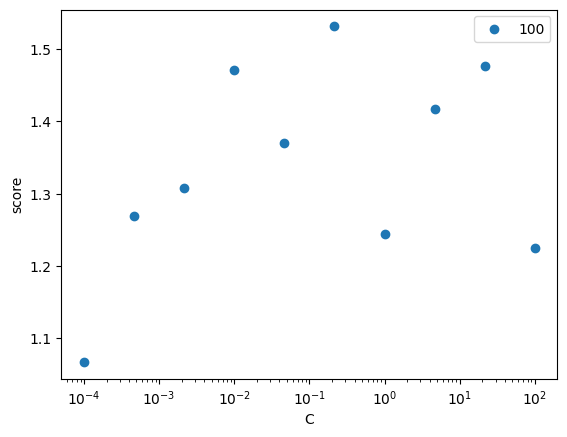

Best C for disease with 100  0.21544346900318823


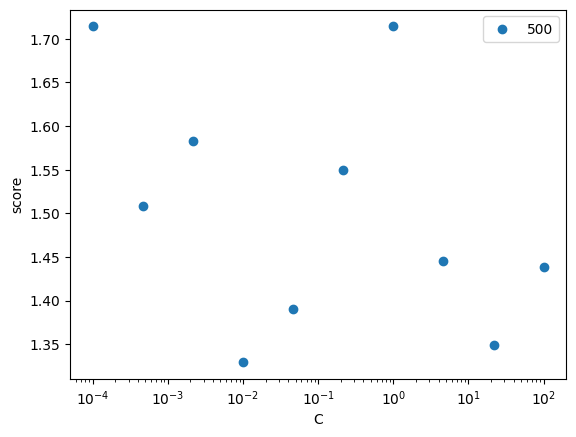

Best C for disease with 500  0.0001
0 2
Best C for disease:  0.0001
Best features for disease:  500


In [35]:
plot_feature_selection_results(Cs, score_risk, features_kept)

**RISK**  
Cross Validation Results:  
Accuracy: 0.66 +/- 0.25  
F1 Macro: 0.64 +/- 0.28  
F1 Weighted: 0.63 +/- 0.27  

In [36]:
Cs = np.logspace(-5, 2, 10)
features_kept = [50, 100, 500]

grid_size = (len(Cs), len(features_kept))

score_mutation = np.zeros(grid_size)

for i, C in enumerate(Cs):
    for j, features in enumerate(features_kept):
        print(f"C: {C}")
        print(f"features: {features}")

        # run the cross validation feature selection
        # to tune the features on the training set
        results = svm_crossval_feature_selection(X_m_train, y_m_train, C=C, features_to_select=features)

        # evaluate the best features on the test set
        X_m_test_best100 = X_m_test[:, results['best_features_i']]

        svm = SVC(kernel='linear', probability=True, C=C)
        score_mutation[i][j] = svm_evaluation_linear(X_m_test_best100, y_m_test)

C: 1e-05
features: 50
Accuracy: 0.62 +/- 0.00
F1 Macro: 0.26 +/- 0.00
F1 Weighted: 0.48 +/- 0.00
Best ranks: [19568 53326 51015 50981 52724 43451 14501 53358 20481 46513 17781 33993
 45768 25420 46691  6824 49207 27001 21591 44670 38427  2849 10981 33765
 45037 19303 34778 41224 47683 47346 37280 21753 54655  5952 40546 10686
 33323 37530 41661 21797 47378 57069 47738 13114 11767 16213 57529 24253
 18336 14136]
Ranks: [1.2 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.4 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6 1.6
 1.6 1.6 1.6 1.6 1.6 1.6 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8 1.8
 1.8 1.8 1.8 1.8 1.8 2.  2.  2.  2.  2.  2.  2.  2.  2. ]

Cross Validation Results:
Accuracy: 0.64 +/- 0.04
F1 Macro: 0.48 +/- 0.13
F1 Weighted: 0.59 +/- 0.07
C: 1e-05
features: 100
Accuracy: 0.62 +/- 0.00
F1 Macro: 0.26 +/- 0.00
F1 Weighted: 0.48 +/- 0.00
Best ranks: [20481 51015 19568 52724 53358  4880 38267 21797 37280  7952 37530 34778
 21934 43451 38427 19303 50981 44670 46691 47378 57069  6824 53326 14501
 45037 34006 457

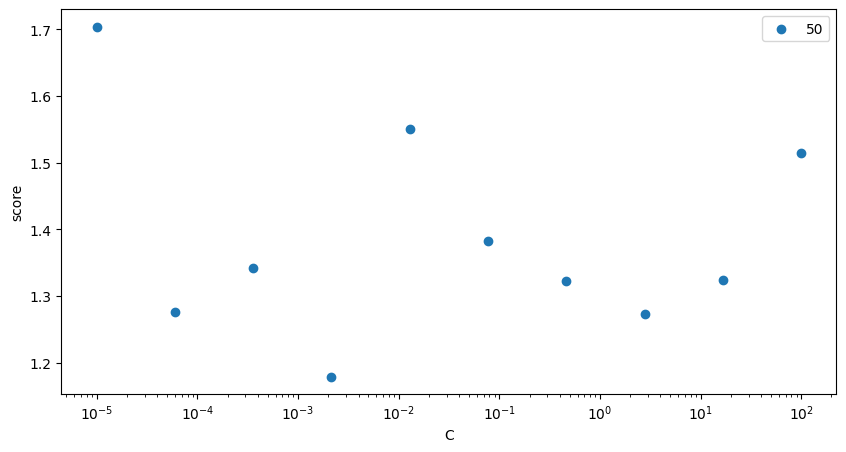

Best C for disease with 50  1e-05


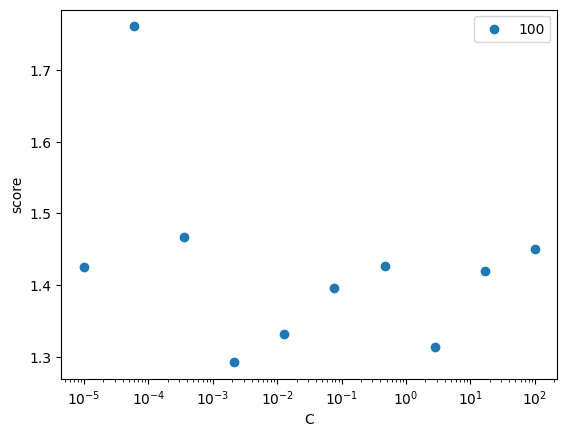

Best C for disease with 100  5.994842503189409e-05


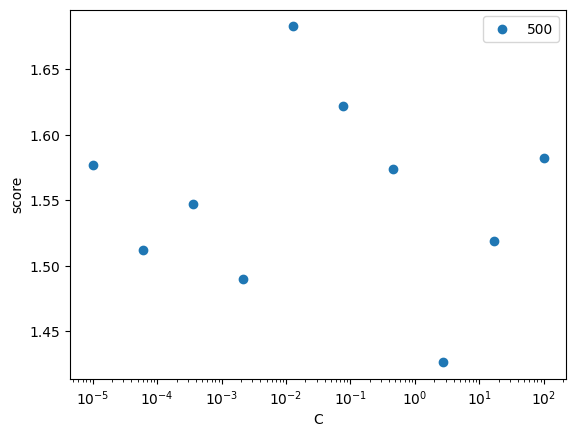

Best C for disease with 500  0.01291549665014884
1 1
Best C for disease:  5.994842503189409e-05
Best features for disease:  100


In [37]:
plot_feature_selection_results(Cs, score_mutation, features_kept)

**MUTATION**  
Cross Validation Results:  
Accuracy: 0.70 +/- 0.16  
F1 Macro: 0.47 +/- 0.12  
F1 Weighted: 0.65 +/- 0.14  

# XGBoost

In [19]:
# data, test_data, label, test_label = train_test_split(RNA_X, y_risk, test_size=0.5)# RNA_X, y_disease
data, test_data, label, test_label = train_test_split(RNA_X, y_mutation, test_size=0.4)# RNA_X, y_disease

In [20]:
def objective(trial, X, y, k=10):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y)
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    test_sample_weights = compute_sample_weight(class_weight='balanced', y=y_test)

    # compute sample weights
    params = {
        "objective": "multi:softmax",
        "num_class": len(np.unique(y)),
        "eval_metric": "mlogloss",
        "max_depth": trial.suggest_int("max_depth", 2, 9),
        "learning_rate": trial.suggest_float("learning_rate", 1e-8, 1.0, log=True),
        "eta": trial.suggest_float("eta", 1e-8, 1.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.1, 1.0),
    }
    
    # interface 1
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-mlogloss")

    bst = xgb.train(
        params, 
        dtrain=xgb.DMatrix(X_train, label=y_train, weight=sample_weights), 
        evals=[(xgb.DMatrix(X_test, label=y_test, weight=test_sample_weights), "validation")],
        callbacks=[pruning_callback],
        verbose_eval=False,
        num_boost_round=trial.suggest_int("n_estimators", 50, 400),
    )
    preds = bst.predict(xgb.DMatrix(X_test))
    y_pred = np.rint(preds)

    # f1_scores = np.zeros(3)

    # interface 2
    # model = XGBClassifier(**params)
    # model.fit(
    #     X_train, y_train, 
    #     sample_weight=sample_weights, 
    #     # eval_set=[(X_test, y_test)], 
    #     # callbacks=[pruning_callback]
    # )
    # y_pred = model.predict(X_test)

    # Calculate the weighted F1 score using sample weights
    return f1_score(y_test, y_pred, average='weighted')

# XGBOOST DISEASE

In [21]:
trainX, testX, trainy, testy = train_test_split(RNA_X, y_disease, test_size=0.5)# RNA_X, y_disease

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, trainX, trainy), n_trials=150)
best_params = study.best_trial.params
best_n_estimators = study.best_trial.n_estimators

[I 2024-01-10 17:29:24,530] A new study created in memory with name: no-name-ec39252e-a54a-4d1a-b106-6954a4d331ee
[I 2024-01-10 17:29:25,661] Trial 0 finished with value: 0.5777777777777777 and parameters: {'max_depth': 9, 'learning_rate': 0.4760816616360426, 'eta': 7.89784147652564e-07, 'gamma': 0.014090199297160606, 'grow_policy': 'lossguide', 'subsample': 0.7165946877947696, 'n_estimators': 54}. Best is trial 0 with value: 0.5777777777777777.
[I 2024-01-10 17:29:32,357] Trial 1 finished with value: 0.7839999999999999 and parameters: {'max_depth': 6, 'learning_rate': 0.05955641764890842, 'eta': 0.003200909903314064, 'gamma': 2.154112261083522e-06, 'grow_policy': 'depthwise', 'subsample': 0.3782108231315765, 'n_estimators': 387}. Best is trial 1 with value: 0.7839999999999999.
[I 2024-01-10 17:29:42,952] Trial 2 finished with value: 0.8384615384615385 and parameters: {'max_depth': 6, 'learning_rate': 8.478161260511987e-05, 'eta': 0.0038372929111912535, 'gamma': 0.061045020381261514, '

AttributeError: 'FrozenTrial' object has no attribute 'n_estimators'

In [22]:
print("DISEASE")

XGBoost_evaluation(testX, testy, best_params=best_params, verbose=True)

DISEASE
Evaluating model...
Best params:  {'max_depth': 6, 'learning_rate': 8.478161260511987e-05, 'eta': 0.0038372929111912535, 'gamma': 0.061045020381261514, 'grow_policy': 'lossguide', 'subsample': 0.47857181628382484, 'n_estimators': 297}

Cross Validation Results:
Accuracy: 0.85 +/- 0.05
F1 Macro: 0.55 +/- 0.15
F1 Weighted: 0.82 +/- 0.06


# XGBOOST RISK

In [18]:
trainX, testX, trainy, testy = train_test_split(RNA_X, y_risk, test_size=0.5)

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, trainX, trainy), n_trials=500)
best_params = study.best_trial.params
best_n_estimators = study.best_trial.n_estimators

[I 2024-01-10 17:29:00,340] A new study created in memory with name: no-name-59a22bdf-7808-465d-a4b3-a087dfd9621b
[W 2024-01-10 17:29:00,342] Trial 0 failed with parameters: {} because of the following error: NameError("name 'objective' is not defined").
Traceback (most recent call last):
  File "/Users/lubojack/micromamba/envs/diploma/lib/python3.11/site-packages/optuna/study/_optimize.py", line 200, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/d_/31s3__pj1dvftkd46s4t27200000gn/T/ipykernel_87017/219799229.py", line 4, in <lambda>
    study.optimize(lambda trial: objective(trial, trainX, trainy), n_trials=500)
                                 ^^^^^^^^^
NameError: name 'objective' is not defined
[W 2024-01-10 17:29:00,351] Trial 0 failed with value None.


NameError: name 'objective' is not defined

In [65]:
XGBoost_evaluation(testX, testy, best_params=best_params, verbose=True, n_estimators=best_n_estimators)

[I 2023-11-28 22:27:58,933] A new study created in memory with name: no-name-faaab608-b984-4fcc-b2b6-ca21443038c7
[I 2023-11-28 22:28:24,407] Trial 0 finished with value: 0.16666666666666666 and parameters: {'max_depth': 7, 'learning_rate': 1.3533637561231781e-08, 'eta': 0.035655333460145905, 'gamma': 2.95541551723485e-06, 'grow_policy': 'lossguide', 'subsample': 0.9974281675727573, 'n_estimators': 135}. Best is trial 0 with value: 0.16666666666666666.
[I 2023-11-28 22:28:54,706] Trial 1 finished with value: 0.4056565656565656 and parameters: {'max_depth': 7, 'learning_rate': 0.019110188914247424, 'eta': 0.00012393236221637166, 'gamma': 6.004279688087016e-05, 'grow_policy': 'lossguide', 'subsample': 0.37835052913728784, 'n_estimators': 292}. Best is trial 1 with value: 0.4056565656565656.
[I 2023-11-28 22:29:14,517] Trial 2 finished with value: 0.5193650793650793 and parameters: {'max_depth': 3, 'learning_rate': 0.03481358709199974, 'eta': 6.134840669757278e-05, 'gamma': 0.000568546238

Evaluating model...
Best params:  {'max_depth': 4, 'learning_rate': 0.003715763282355658, 'eta': 3.4418785070745603e-05, 'gamma': 0.00013172471459226427, 'grow_policy': 'lossguide', 'subsample': 0.7476997525913225, 'n_estimators': 259}

Cross Validation Results:
Accuracy: 0.53 +/- 0.08
F1 Macro: 0.44 +/- 0.07
F1 Weighted: 0.49 +/- 0.07


In [78]:
print("RISK")
XGBoost_evaluation(testX, testy, best_params=best_params, verbose=True)

RISK
Evaluating model...
Best params:  {'max_depth': 7, 'learning_rate': 0.2855297058083325, 'eta': 1.196739962322773e-07, 'gamma': 0.08119813036260252, 'grow_policy': 'lossguide', 'subsample': 0.38372573011653677, 'n_estimators': 87}

Cross Validation Results:
Accuracy: 0.48 +/- 0.16
F1 Macro: 0.38 +/- 0.16
F1 Weighted: 0.44 +/- 0.17


In [56]:
print("RISK")
XGBoost_evaluation(testX, testy, best_params={'max_depth': 7, 'learning_rate': 0.08647757604634682, 'eta': 6.902879226848567e-05, 'gamma': 0.924063477518098, 'grow_policy': 'depthwise', 'subsample': 0.5714747103868317, 'n_estimators': 313}, verbose=True)

RISK
Evaluating model...
Best params:  {'max_depth': 7, 'learning_rate': 0.08647757604634682, 'eta': 6.902879226848567e-05, 'gamma': 0.924063477518098, 'grow_policy': 'depthwise', 'subsample': 0.5714747103868317, 'n_estimators': 313}

Cross Validation Results:
Accuracy: 0.45 +/- 0.10
F1 Macro: 0.39 +/- 0.10
F1 Weighted: 0.41 +/- 0.10


# XGBOOST MUTATION

In [57]:
trainX, testX, trainy, testy = train_test_split(RNA_X, y_mutation, test_size=0.5)

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective(trial, trainX, trainy), n_trials=40)
best_params = study.best_trial.params

XGBoost_evaluation(testX, testy, best_params=best_params, verbose=True)

[I 2023-11-29 23:50:31,628] A new study created in memory with name: no-name-a7b67483-1ebe-494f-a8dc-642f103c512f
[I 2023-11-29 23:50:46,552] Trial 0 finished with value: 0.6555555555555554 and parameters: {'max_depth': 5, 'learning_rate': 2.3904766261991806e-05, 'eta': 2.2245525937055866e-06, 'gamma': 0.008915944494373319, 'grow_policy': 'lossguide', 'subsample': 0.6019732052516732, 'n_estimators': 224}. Best is trial 0 with value: 0.6555555555555554.
[I 2023-11-29 23:51:09,317] Trial 1 finished with value: 0.6112280701754386 and parameters: {'max_depth': 3, 'learning_rate': 2.3905613747085454e-07, 'eta': 0.045667859706780056, 'gamma': 1.8693026575090294e-07, 'grow_policy': 'depthwise', 'subsample': 0.8585469051320727, 'n_estimators': 88}. Best is trial 0 with value: 0.6555555555555554.
[I 2023-11-29 23:51:45,003] Trial 2 finished with value: 0.5293233082706765 and parameters: {'max_depth': 7, 'learning_rate': 5.1230657751795474e-06, 'eta': 0.06305103604424021, 'gamma': 9.448070376204

Evaluating model...
Best params:  {'max_depth': 5, 'learning_rate': 2.3904766261991806e-05, 'eta': 2.2245525937055866e-06, 'gamma': 0.008915944494373319, 'grow_policy': 'lossguide', 'subsample': 0.6019732052516732, 'n_estimators': 224}

Cross Validation Results:
Accuracy: 0.67 +/- 0.08
F1 Macro: 0.39 +/- 0.16
F1 Weighted: 0.60 +/- 0.09


In [58]:
print("MUTATION")
XGBoost_evaluation(testX, testy, best_params=best_params, verbose=True)

MUTATION
Evaluating model...
Best params:  {'max_depth': 5, 'learning_rate': 2.3904766261991806e-05, 'eta': 2.2245525937055866e-06, 'gamma': 0.008915944494373319, 'grow_policy': 'lossguide', 'subsample': 0.6019732052516732, 'n_estimators': 224}

Cross Validation Results:
Accuracy: 0.64 +/- 0.06
F1 Macro: 0.35 +/- 0.12
F1 Weighted: 0.56 +/- 0.07


# Logistic regression

In [46]:
# Standardize the train and test sample
scaler = StandardScaler()
X_std = scaler.fit_transform(RNA_X)

# Perform GridSearchCV to tune best-fit LR model
param = {'C': np.linspace(10**-2, 10, 30)}

In [47]:
lr_model = LogisticRegression(
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
gs_model = GridSearchCV(estimator=lr_model, param_grid=param)
gs_model.fit(X_std, y_disease)

# Train a LR model with best parameters
model = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
model.fit(X_std, y_disease)

LogisticRegression(C=2.765862068965517, class_weight='balanced', penalty='l1',
                   solver='liblinear')

In [59]:
np.unique(y_disease, return_counts=True)

(array([0, 1]), array([13, 61]))

predsa [1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1]
[0.44444444 0.75       0.80555556 1.         0.66666667]
roc_auc: 0.73 +/- 0.18


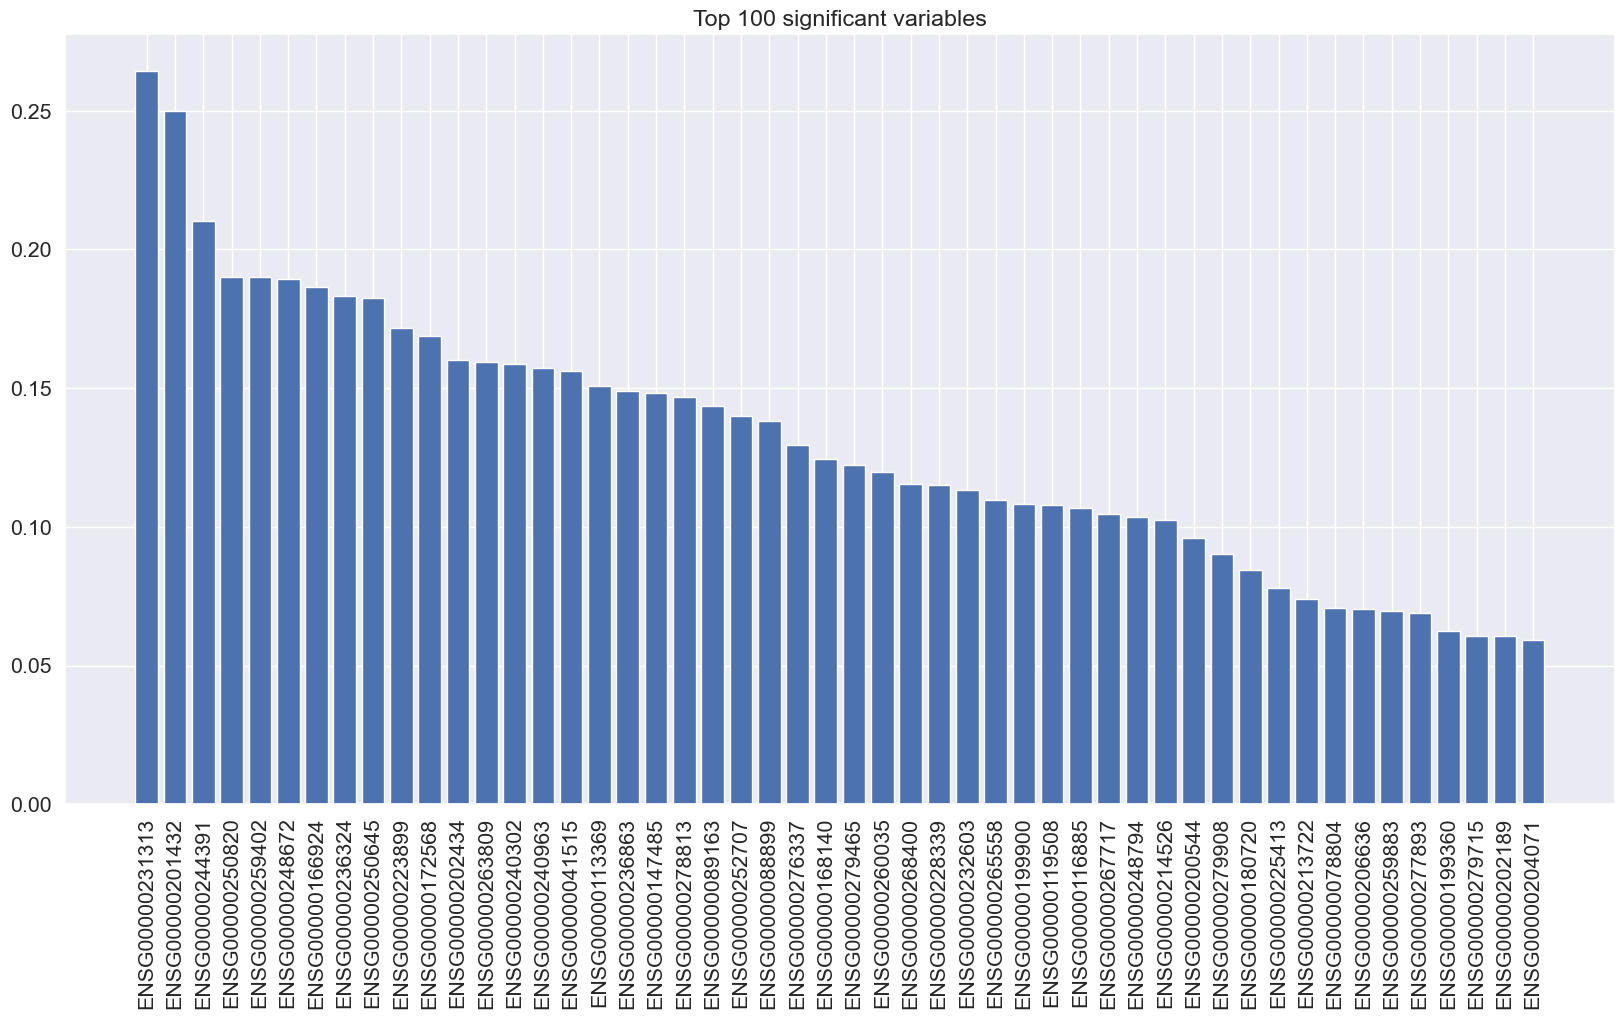

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1]


<Axes: >

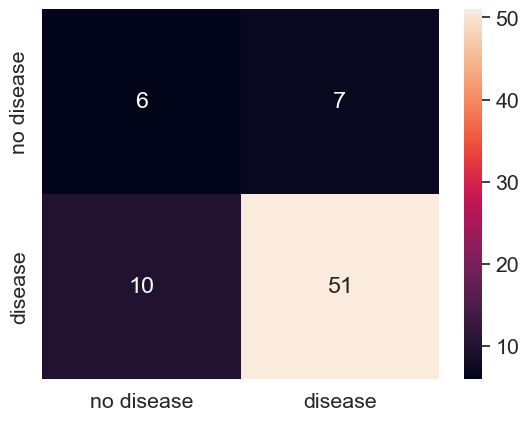

In [57]:
# perform cross-validation for the best model
lr = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
scores = cross_val_score(
    lr, X_std, y_disease, cv=5, scoring='roc_auc'
)
preds = cross_val_predict(
    lr, X_std, y_disease, cv=5, method='predict'
)

print("predsa", preds)

print(scores)
print("roc_auc: %0.2f +/- %0.2f" % (scores.mean(), scores.std()))

features = (RNA.lazy()
            .select(["GENE_ID"])
            .collect()).to_numpy().flatten()
features

d = np.column_stack((features, abs(model.coef_[0])))
significant_varsl1 = d[d[:, 1].argsort()][::-1]
# barplot of the top 50 significant variables
plt.figure(figsize=(20, 10))
plt.bar(significant_varsl1[:50, 0], significant_varsl1[:50, 1])
plt.xticks(rotation=90)
plt.title("Top 100 significant variables")
plt.show()

# y_pred = model.predict(X_std)

print(y_disease)
print(preds)

cmtx = confusion_matrix(y_disease, preds, labels=[0,1])

df_cm = pd.DataFrame(cmtx, columns=["no disease", "disease"])
df_cm.index = ["no disease", "disease"]
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True) # font size